In [155]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy
import pandas as pd
import time

In [157]:
#import data from CAVIAR study
phases = {}
G = {}
num_phases=12
for i in range(1,num_phases): 
  var_name = "phase" + str(i)
  file_name = "https://raw.githubusercontent.com/ragini30/Networks-Homework/main/" + var_name + ".csv"
    
  phases[i] = pd.read_csv(file_name, index_col = ["players"])
  phases[i].columns = "n" + phases[i].columns
  phases[i].index = phases[i].columns
  phases[i][phases[i] > 0] = 1
  G[i] = nx.from_pandas_adjacency(phases[i],create_using = nx.DiGraph())
  G[i].name = var_name

OSError: 

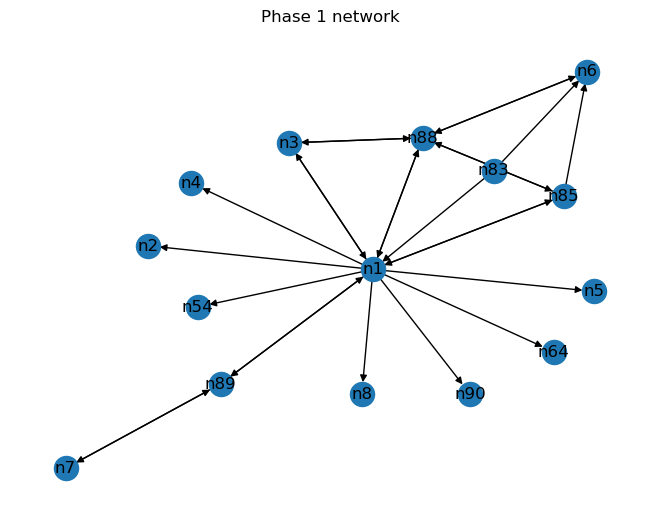

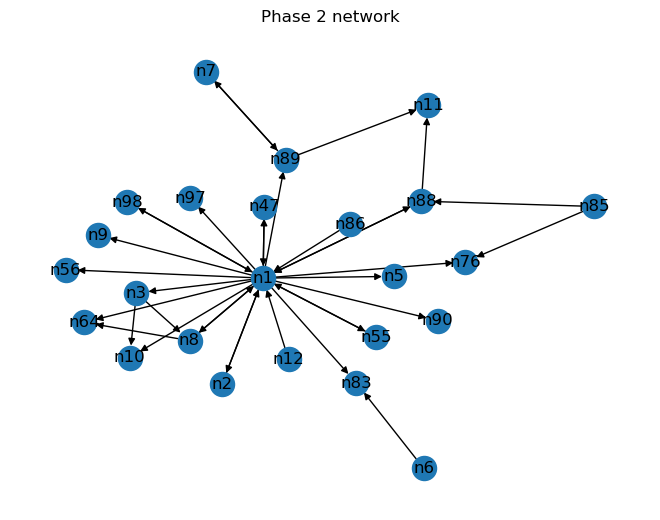

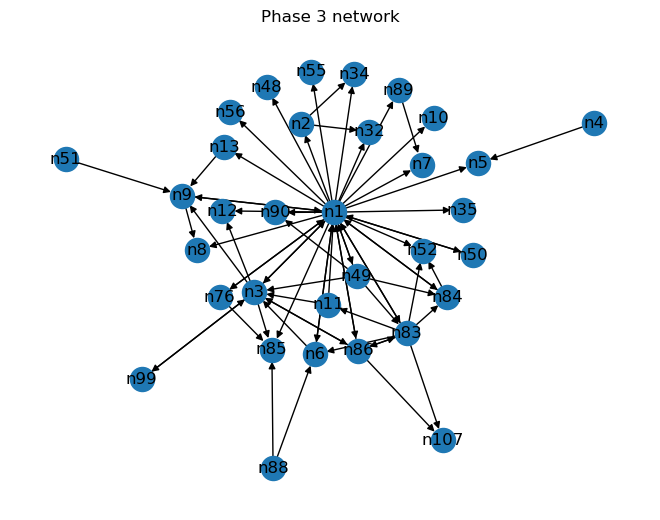

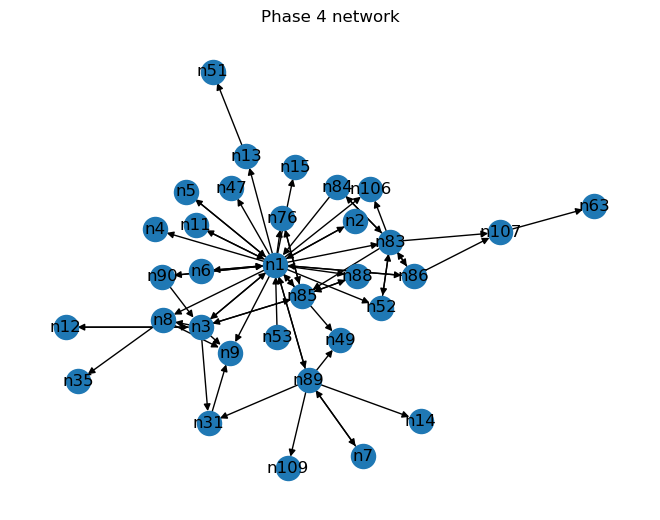

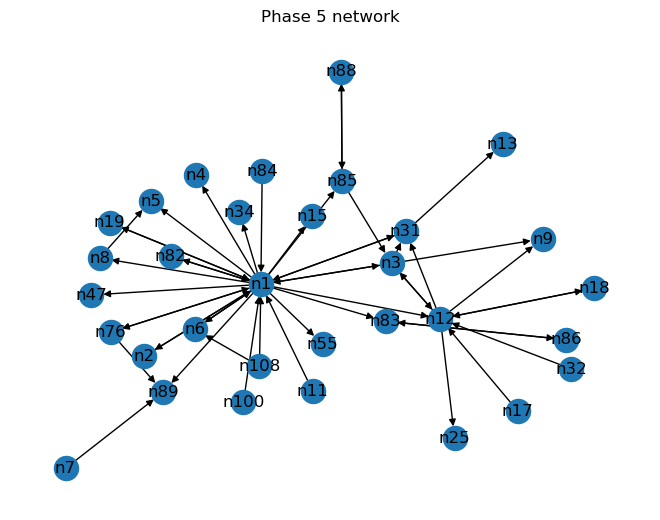

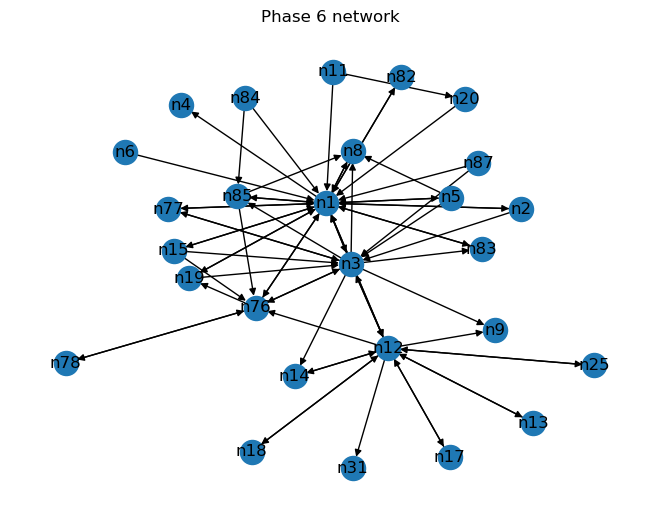

<Figure size 640x480 with 0 Axes>

In [159]:
#plot network graph for each phase
for i in range(1,num_phases):
    g=G[i]
    nx.draw(g, pos=nx.drawing.nx_agraph.graphviz_layout(g), with_labels=True)
    plt.title('Phase {} network'.format(i))
    plt.figure()

In [167]:
#calculate top centrality of each type up to the highest rnk_max-1 and report each top player and respective value
rnk_max=6

deg_cent=np.array([])
bet_cent=np.array([])
eig_cent=np.array([])
for i in range(len(G)):
    phase_cur=G[i+1]
    deg_cent=np.append(deg_cent,nx.degree_centrality(phase_cur))
    bet_cent=np.append(bet_cent,nx.betweenness_centrality(phase_cur, normalized = True))
    eig_cent=np.append(eig_cent,nx.eigenvector_centrality(phase_cur))

for i in range(1,111):
    pl_cur='n{}'.format(i)
    deg_arr=np.array([])
    bet_arr=np.array([])
    eig_arr=np.array([])
    for j in range(2,len(G)):
        if np.isin(pl_cur,phases[j+1].columns):
            deg_arr=np.append(deg_arr,deg_cent[j][pl_cur])
            eig_arr=np.append(eig_arr,eig_cent[j][pl_cur])
            bet_arr=np.append(bet_arr,bet_cent[j][pl_cur])
        else:
            deg_arr=np.append(deg_arr,0)
            eig_arr=np.append(eig_arr,0)
            bet_arr=np.append(bet_arr,0)
    if i>1:
        pl_deg_cent=np.vstack((pl_deg_cent,deg_arr))
        pl_eig_cent=np.vstack((pl_eig_cent,eig_arr))
        pl_bet_cent=np.vstack((pl_bet_cent,bet_arr))
    else:
        pl_deg_cent=deg_arr
        pl_eig_cent=eig_arr
        pl_bet_cent=bet_arr

deg_cent_means=np.mean(pl_deg_cent,axis=1)
eig_cent_means=np.mean(pl_eig_cent,axis=1)
bet_cent_means=np.mean(pl_bet_cent,axis=1)
deg_sort=np.sort(deg_cent_means)
deg_ind=np.argsort(deg_cent_means)
eig_sort=np.sort(eig_cent_means)
eig_ind=np.argsort(eig_cent_means)
bet_sort=np.sort(bet_cent_means)
bet_ind=np.argsort(bet_cent_means)

top_deg = np.array([deg_ind[-i] for i in range(1,rnk_max)])
top_deg_val = np.array([deg_sort[-i] for i in range(1,rnk_max)])
top_eig = np.array([eig_ind[-i] for i in range(1,rnk_max)])
top_eig_val = np.array([eig_sort[-i] for i in range(1,rnk_max)])
top_bet = np.array([bet_ind[-i] for i in range(1,rnk_max)])
top_bet_val = np.array([bet_sort[-i] for i in range(1,rnk_max)])
print('Top Degree Centrality ([Players] [Values]) \n',top_deg+1,top_deg_val,'\n Top Eigenvalue Centrality \n',top_eig+1,top_eig_val,\
      '\n Top Betweenness Centrality \n',top_bet+1,top_bet_val)

Top Degree Centrality ([Players] [Values]) 
 [ 1  3 12 76 85] [0.78899353 0.32146255 0.28874298 0.17750799 0.156104  ] 
 Top Eigenvalue Centrality 
 [ 1  3 85 76  8] [0.47060608 0.25889653 0.22705189 0.21639597 0.17365881] 
 Top Betweenness Centrality 
 [ 1 12  3 76 87] [0.29024101 0.10174754 0.08845432 0.03907306 0.03599233]


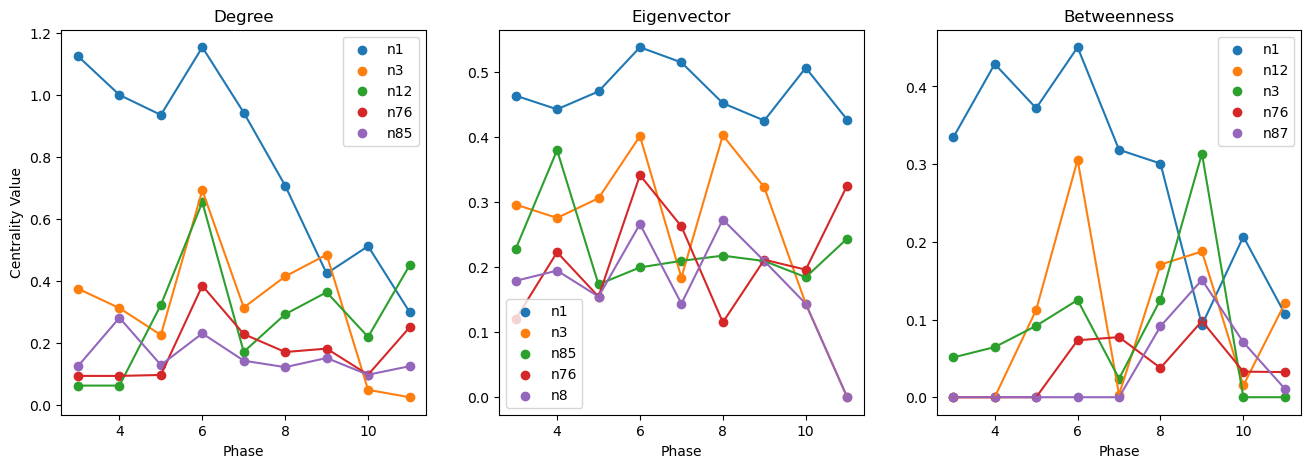

In [163]:
#plot each centrality value accross phases for each of top 5 players
fig,ax=plt.subplots(1,3,figsize=(16,5))
cents=[pl_deg_cent,pl_eig_cent,pl_bet_cent]
tops=[top_deg,top_eig,top_bet]
mns=[deg_cent_means,eig_cent_means,bet_cent_means]
ids=[deg_ind,eig_ind,bet_ind]
srs=[deg_sort,eig_sort,bet_sort]
ttls=['Degree','Eigenvector','Betweenness']
x_val=range(3,len(G)+1)
for i in range(3):
    pls=tops[i]
    cent=cents[i]
    ax_cur=ax[i]
    for j in pls:
        c_cur=cent[j]
        ax_cur.scatter(x_val,c_cur,label='n{}'.format(j+1))
        ax_cur.plot(x_val,c_cur)
    ax[i].legend()
    ax[i].set_xlabel('Phase')
    ax[i].set_title(ttls[i])
ax[0].set_ylabel('Centrality Value')
plt.savefig('centrality_measures_1.png',dpi=300)